In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [3]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [4]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [5]:
G_hi = 20.5
G_lo = 20.0

In [6]:
nthreads = 18

In [7]:
mask_type = 'selfunc'

# Visuals

In [8]:
tab_datalo, pixel_indices_datalo_mask, N_datalo_mask, mask_datalo = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, mask_type = 'selfunc')

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [9]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [10]:
cmap_reds = sns.color_palette("Reds_r", as_cmap = True)
cmap_blues = sns.color_palette("Blues_r", as_cmap = True)

In [11]:
# z_array = [0,1]
zbin_array = [0.0,1.0,2.0,3.0,4.0]
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(zbin_array)-1))
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(zbin_array)-1))
cmaps = [cmap_red, cmap_blue]

In [12]:
blue = np.mean(cmap_blue, axis = 0)
red = np.mean(cmap_red, axis = 0)
blue = plt.get_cmap('Blues')((0.333+0.999)/2)
red = plt.get_cmap('Reds')((0.333+0.999)/2)
colors = [red, blue]
# mag = [G_hi, G_lo]
G_array = [G_lo, G_hi]

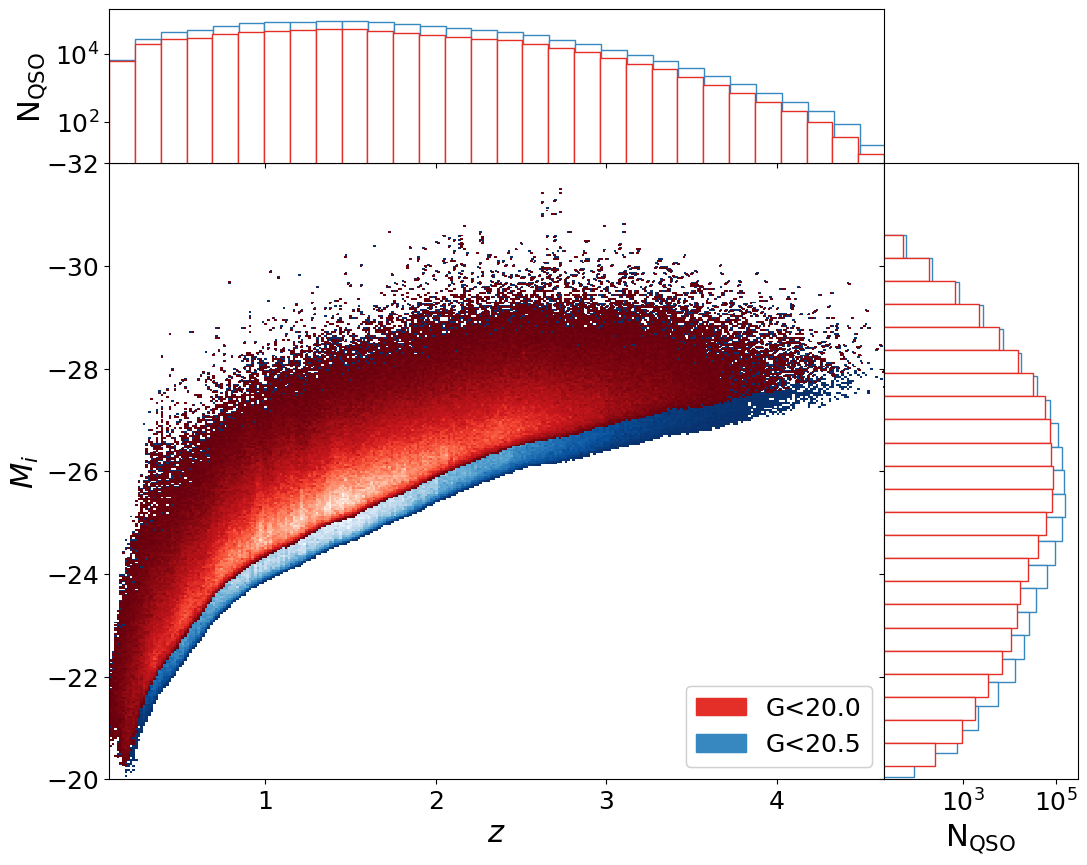

In [13]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
quaia.absolute(tab_datalo, G_lo)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap_blues, bins = 300, 
                                       cmin = 1)
h1, xedges, yedges, image = ax1.hist2d(tab_datalo['redshift_quaia'][mask_datalo], tab_datalo['M_i'][mask_datalo], cmap = cmap_reds, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()
patch = [mpatches.Patch(color=colors[i], label='G<{}'.format(G_array[i])) for i in range(len(colors))] 
first_legend = ax1.legend(handles=patch, loc = 'lower right')
ax1.add_artist(first_legend)

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = blue, bins = 30)
ax2.hist(tab_datalo['redshift_quaia'][mask_datalo], color = 'white', edgecolor = red, bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = blue, orientation = 'horizontal', bins = 25)
ax3.hist(tab_datalo['M_i'][mask_datalo], color = 'white', edgecolor = red, orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Understand facrand
## $\xi(s)$

In [15]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# # Create the bins array
# rmin = 0.1 # 0.1 # start higher
# rmax = 155.0 # 20.0 #50.0
# nbins = 20 #90 #20
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [16]:
# plot!
cf_test = {G_lo: [], G_hi: []}
cf_test_allsky = {G_lo: [], G_hi: []}
facrand = [10, 25, 50, 100]
for j in range(len(facrand)):
    
    for i in range(len(colors)):

        fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_array[i])
        selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

        tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read('../data/quaia_G{}.fits'.format(G_array[i]), G_array[i], 
                                                                                       fn_selhi, mask_type = mask_type)

        # regular method
        tab_randhi, pixel_indices_randhi_mask, N_randhi_mask, mask_randhi = quaia.read('../data/randoms/random_G{}_{}x.fits'.format(G_array[i], 
                                                                                                                                    facrand[j]), 
                                                                                       G_array[i], fn_selhi, mask_type = mask_type)
        key = quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
        cf_test[G_array[i]].append(quaia.xi_s(tab_datahi[mask_datahi], tab_randhi[mask_randhi], key, nthreads = nthreads, rbins = rbins))

        # upweighted method
        (tab_randhi_allsky, pixel_indices_randhi_mask_allsky, N_randhi_mask_allsky, 
         mask_randhi_allsky) = quaia.read('../data/randoms/random_G{}_allsky_{}x.fits'.format(G_array[i], facrand[j]), G_array[i], fn_selhi, 
                                          mask_type = mask_type)
        key_allsky = quaia.z_dist(tab_datahi, tab_randhi_allsky,  mask_datahi, mask_randhi_allsky, N_datahi_mask, N_randhi_mask_allsky, 
                                  mask_type = 'allsky')
        cf_test_allsky[G_array[i]].append(quaia.xi_s(tab_datahi[mask_datahi], tab_randhi_allsky[mask_randhi_allsky], key_allsky, nthreads = nthreads,
                                          rbins = rbins, weights1 = 1/selfunc_hi[pixel_indices_datahi_mask]))

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 7563151
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 12904608
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 12955802
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


...

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 129616435
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 260110147
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


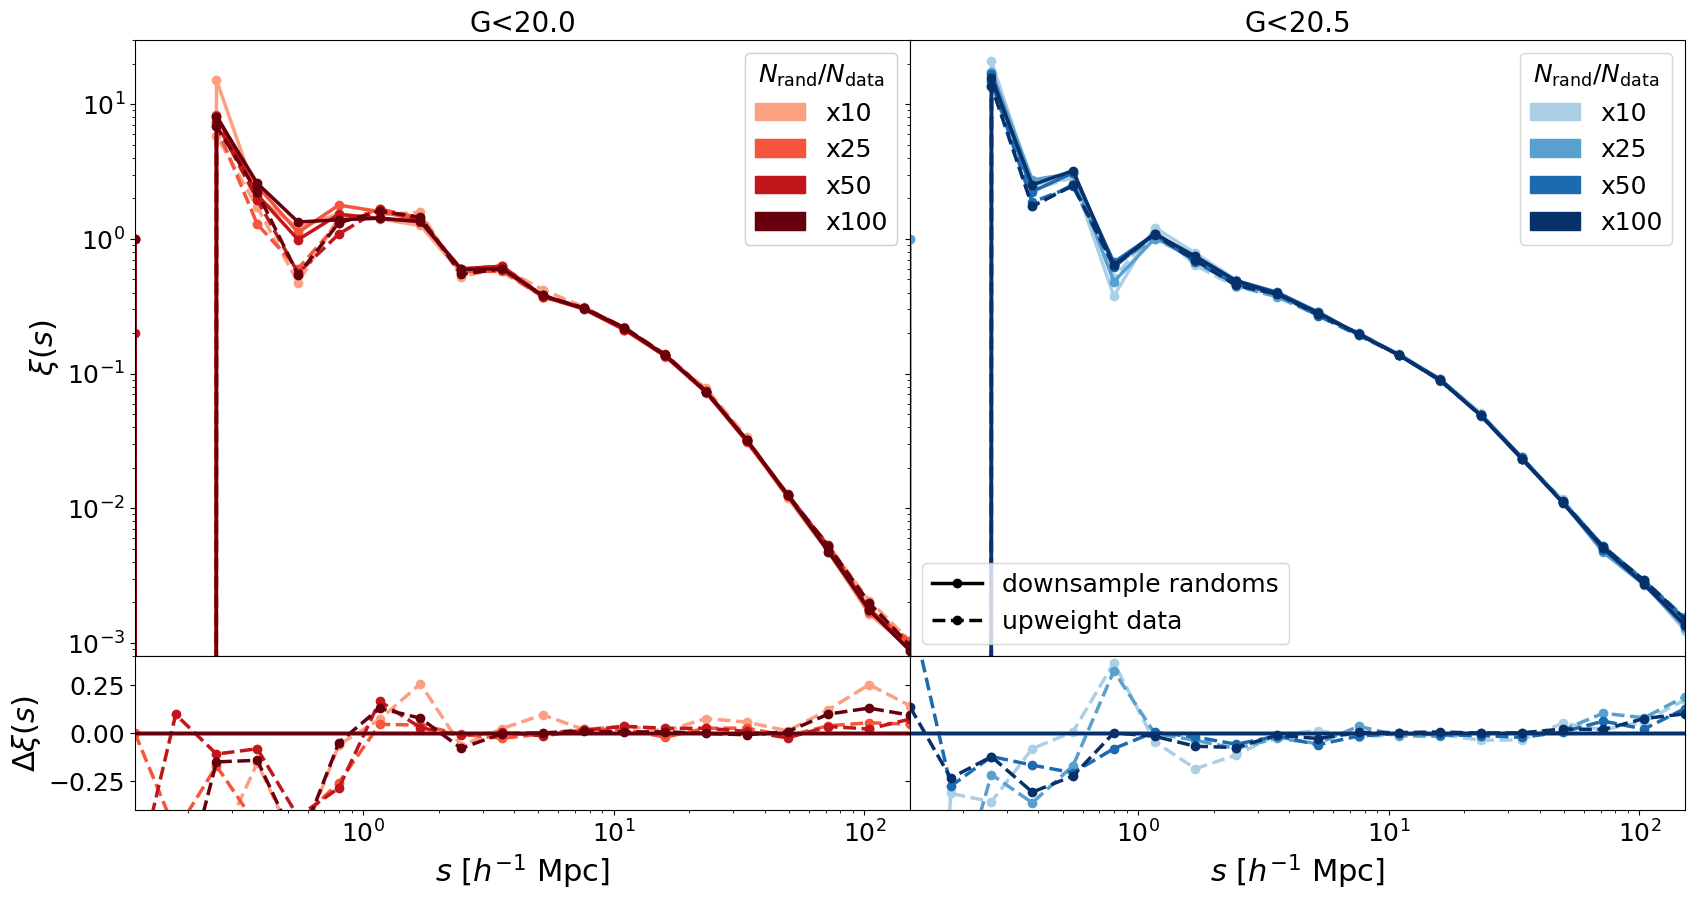

In [17]:
# plot!
fig = plt.figure(figsize = (20, 10))
gs = gridspec.GridSpec(2, 2, wspace = 0, height_ratios = [4,1], hspace = 0)
    
for i in range(len(colors)):

    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])
    
    for j in range(len(facrand)):
        
        ax1.plot(quaia.recenter(rbins), cf_test[G_array[i]][j], marker = 'o', label = 'downsample randoms', 
                     linewidth = 2.5, color = cmaps[i][j])
        ax1.plot(quaia.recenter(rbins), cf_test_allsky[G_array[i]][j], marker = 'o', label = 'upweight data', 
                     linewidth = 2.5, color = cmaps[i][j], linestyle = '--')

        ax1.set_title('G<{}'.format(G_array[i]))
        ax1.set_xticklabels([])
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(8e-4, 3e1)
    
        ax2.axhline(0, linewidth = 2.5,color = cmaps[i][j])
        ax2.plot(quaia.recenter(rbins), (cf_test_allsky[G_array[i]][j]-cf_test[G_array[i]][j])/cf_test[G_array[i]][j], marker = 'o', 
                 label = 'x{}'.format(facrand[j]), linewidth = 2.5, color = cmaps[i][j], linestyle = '--')
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax2.set_ylim(-0.4, 0.4)

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if i == 0:
            ax1.set_ylabel(r"$\xi(s)$")
            ax2.set_ylabel(r"$\Delta\xi(s)$")
        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])
            
    patch = [mpatches.Patch(color=cmaps[i][k], label='x{}'.format(facrand[k])) for k in range(len(cmaps[i]))]
    first_legend = ax1.legend(handles=patch, loc = 'upper right', title = "$N_\mathrm{rand}/N_\mathrm{data}$", title_fontsize = 18)
    ax1.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '-', marker = 'o'), 
                Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '--', marker = 'o')]
ax1.legend(custom_lines, ['downsample randoms', 'upweight data'], loc = 'lower left')

plt.show()

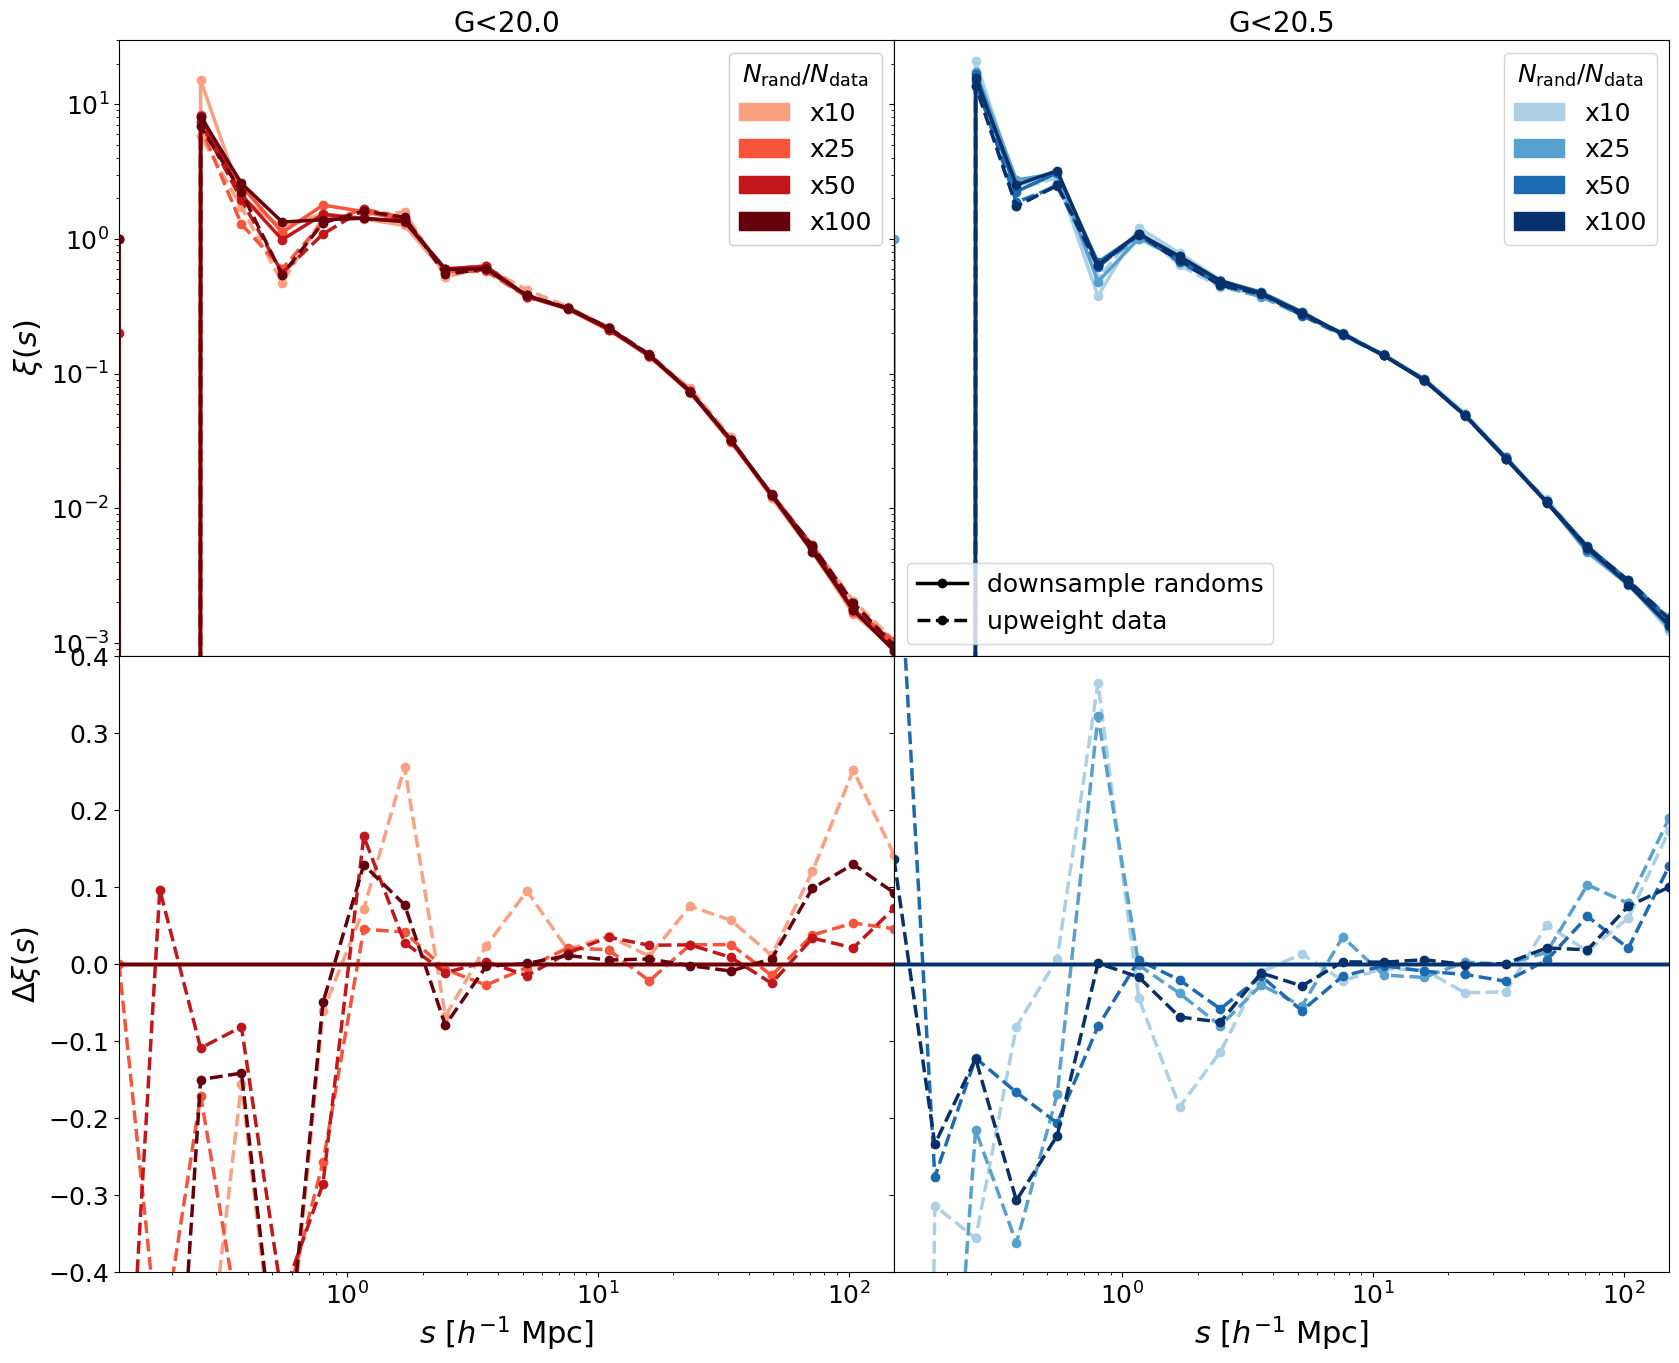

In [18]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0)
    
for i in range(len(colors)):

    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])
    
    for j in range(len(facrand)):
        
        ax1.plot(quaia.recenter(rbins), cf_test[G_array[i]][j], marker = 'o', label = 'downsample randoms', 
                     linewidth = 2.5, color = cmaps[i][j])
        ax1.plot(quaia.recenter(rbins), cf_test_allsky[G_array[i]][j], marker = 'o', label = 'upweight data', 
                     linewidth = 2.5, color = cmaps[i][j], linestyle = '--')

        ax1.set_title('G<{}'.format(G_array[i]))
        ax1.set_xticklabels([])
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(8e-4, 3e1)
    
        ax2.axhline(0, linewidth = 2.5,color = cmaps[i][j])
        ax2.plot(quaia.recenter(rbins), (cf_test_allsky[G_array[i]][j]-cf_test[G_array[i]][j])/cf_test[G_array[i]][j], marker = 'o', 
                 label = 'x{}'.format(facrand[j]), linewidth = 2.5, color = cmaps[i][j], linestyle = '--')
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax2.set_ylim(-0.4, 0.4)

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if i == 0:
            ax1.set_ylabel(r"$\xi(s)$")
            ax2.set_ylabel(r"$\Delta\xi(s)$")
        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])
            
    patch = [mpatches.Patch(color=cmaps[i][k], label='x{}'.format(facrand[k])) for k in range(len(cmaps[i]))]
    first_legend = ax1.legend(handles=patch, loc = 'upper right', title = "$N_\mathrm{rand}/N_\mathrm{data}$", title_fontsize = 18)
    ax1.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '-', marker = 'o'), 
                Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '--', marker = 'o')]
ax1.legend(custom_lines, ['downsample randoms', 'upweight data'], loc = 'lower left')

plt.show()

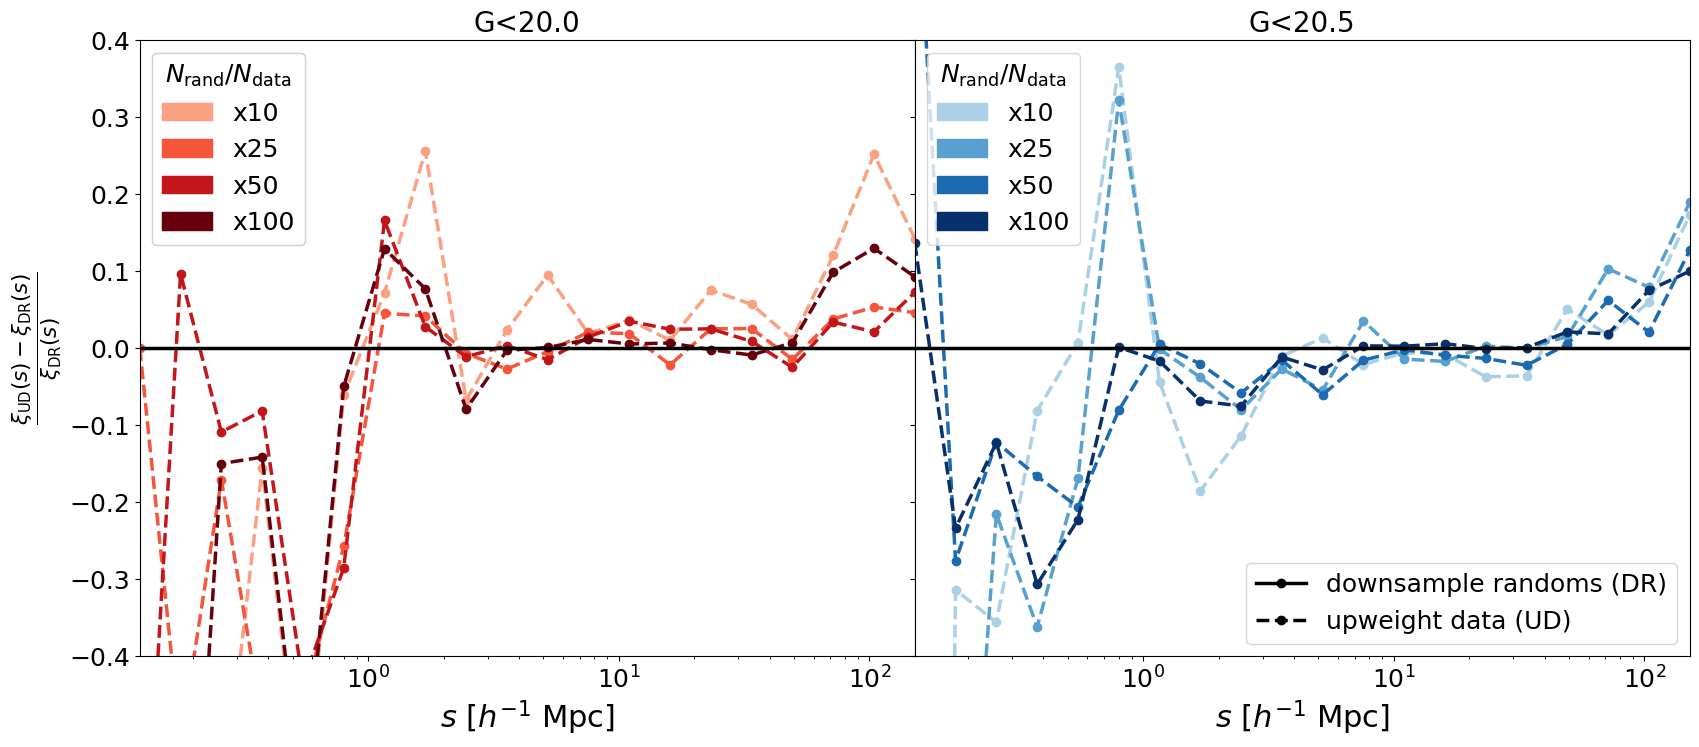

In [19]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

for i in range(len(colors)):

    ax1 = fig.add_subplot(gs[i])
    
    for j in range(len(facrand)):

        ax1.plot(quaia.recenter(rbins), (cf_test_allsky[G_array[i]][j]-cf_test[G_array[i]][j])/cf_test[G_array[i]][j], marker = 'o', 
                 label = 'x{}'.format(facrand[j]), linewidth = 2.5, color = cmaps[i][j], linestyle = '--')
    
    ax1.set_title('G<{}'.format(G_array[i]))    
    ax1.axhline(0, linewidth = 2.5,color = 'black')
    ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(-0.4, 0.4)

    if scale == 'log':
        ax1.set_xscale('log')

    if i == 0:
        ax1.set_ylabel(r"$\frac{\xi_\mathrm{UD}(s)-\xi_\mathrm{DR}(s)}{\xi_\mathrm{DR}(s)}$")
    else:
        ax1.set_yticklabels([])

    patch = [mpatches.Patch(color=cmaps[i][k], label='x{}'.format(facrand[k])) for k in range(len(cmaps[i]))]
    first_legend = ax1.legend(handles=patch, loc = 'upper left', title = "$N_\mathrm{rand}/N_\mathrm{data}$", title_fontsize = 18)
    ax1.add_artist(first_legend)
    
custom_lines = [Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '-', marker = 'o'), 
                Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '--', marker = 'o')]
ax1.legend(custom_lines, ['downsample randoms (DR)', 'upweight data (UD)'], loc = 'lower right')

plt.show()

## $w_p(r_p)$

In [20]:
# Create the bins array
rmin = 0.15 # 0.5 # 0.1 # start higher
rmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# rmin = 0.15 # 0.5 # 0.1 # start higher
# rmax = 210 # 120 #85 # 60.0 # 20.0 
# nbins = 20 
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [21]:
pimax = 80 # 40 # 5000.0 # 40.0

In [22]:
wp_test = {G_lo: [], G_hi: []}
rpavg_test = {G_lo: [], G_hi: []}
wp_test_allsky = {G_lo: [], G_hi: []}
rpavg_test_allsky = {G_lo: [], G_hi: []}
facrand = [10, 25, 50, 100]
for j in range(len(facrand)):
    
    for i in range(len(colors)):


        fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_array[i])
        selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

        tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read('../data/quaia_G{}.fits'.format(G_array[i]), G_array[i], 
                                                                                       fn_selhi, mask_type = mask_type)

        # regular method
        tab_randhi, pixel_indices_randhi_mask, N_randhi_mask, mask_randhi = quaia.read('../data/randoms/random_G{}_{}x.fits'.format(G_array[i], 
                                                                                                                                    facrand[j]), 
                                                                                       G_array[i], fn_selhi, mask_type = mask_type)
        key = quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
        wp, rpavg = quaia.wp_rp(tab_datahi[mask_datahi], tab_randhi[mask_randhi], key, nthreads = nthreads, rbins = rbins, 
                                                           nbins = nbins, pimax = pimax)
        
        np.save('../results/wp_G{}_{}x'.format(G_array[i], facrand[j]), wp)
        np.save('../results/rpavg_G{}_{}x'.format(G_array[i], facrand[j]), rpavg)
        
        wp_test[G_array[i]].append(wp)
        rpavg_test[G_array[i]].append(rpavg)

        # upweighted method
        (tab_randhi_allsky, pixel_indices_randhi_mask_allsky, N_randhi_mask_allsky, 
         mask_randhi_allsky) = quaia.read('../data/randoms/random_G{}_allsky_{}x.fits'.format(G_array[i], facrand[j]), G_array[i], fn_selhi, 
                                          mask_type = mask_type)
        key_allsky = quaia.z_dist(tab_datahi, tab_randhi_allsky,  mask_datahi, mask_randhi_allsky, N_datahi_mask, N_randhi_mask_allsky, 
                                  mask_type = 'allsky')
        wp, rpavg = quaia.wp_rp(tab_datahi[mask_datahi], tab_randhi_allsky[mask_randhi_allsky], key_allsky, 
                                                      nthreads = nthreads, rbins = rbins, nbins = nbins, pimax = pimax, 
                                                      weights1 = 1/selfunc_hi[pixel_indices_datahi_mask])
        
        np.save('../results/wp_G{}_allsky_{}x'.format(G_array[i], facrand[j]), wp)
        np.save('../results/rpavg_G{}_allsky_{}x'.format(G_array[i], facrand[j]), rpavg)
        
        wp_test_allsky[G_array[i]].append(wp)
        rpavg_test_allsky[G_array[i]].append(rpavg)

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 7563151
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 12904608
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 12955802
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


...

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 129616435
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 260110147
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


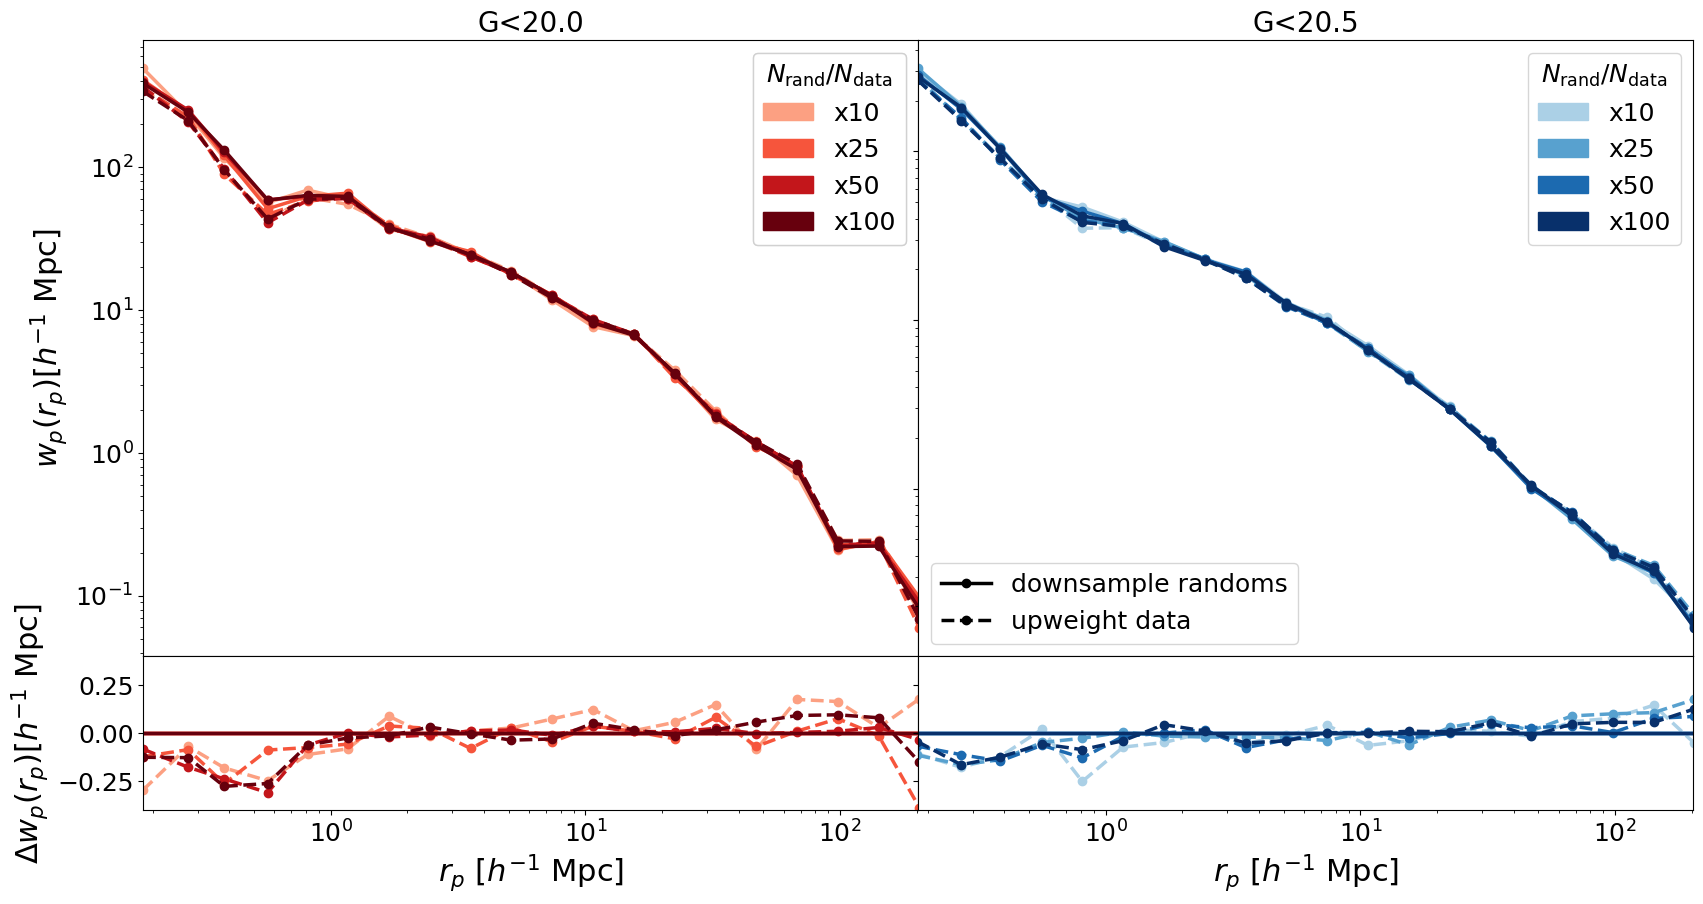

In [23]:
# plot!
fig = plt.figure(figsize = (20, 10))
gs = gridspec.GridSpec(2, 2, wspace = 0, height_ratios = [4,1], hspace = 0)
    
for i in range(len(colors)):

    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])
    
    for j in range(len(facrand)):

        ax1.plot(rpavg_test[G_array[i]][j], wp_test[G_array[i]][j], marker = 'o', label = 'downsample randoms', 
                     linewidth = 2.5, color = cmaps[i][j])

        # upweighted method
        ax1.plot(rpavg_test_allsky[G_array[i]][j], wp_test_allsky[G_array[i]][j], marker = 'o', label = 'upweight data', 
                     linewidth = 2.5, color = cmaps[i][j], linestyle = '--')

        ax1.set_title('G<{}'.format(G_array[i]))
        ax1.set_xticklabels([])
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])

        ax2.axhline(0, linewidth = 2.5,color = cmaps[i][j])
        ax2.plot(rpavg_test_allsky[G_array[i]][j], (wp_test_allsky[G_array[i]][j]-wp_test[G_array[i]][j])/wp_test[G_array[i]][j], marker = 'o', 
                 label = 'x{}'.format(facrand[j]), linewidth = 2.5, color = cmaps[i][j], linestyle = '--')
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax2.set_ylim(-0.4, 0.4)

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if i == 0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
            ax2.set_ylabel(r"$\Delta w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])
            
    patch = [mpatches.Patch(color=cmaps[i][k], label='x{}'.format(facrand[k])) for k in range(len(cmaps[i]))]
    first_legend = ax1.legend(handles=patch, loc = 'upper right', title = "$N_\mathrm{rand}/N_\mathrm{data}$", title_fontsize = 18)
    ax1.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '-', marker = 'o'), 
                Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '--', marker = 'o')]
ax1.legend(custom_lines, ['downsample randoms', 'upweight data'], loc = 'lower left')

plt.show()

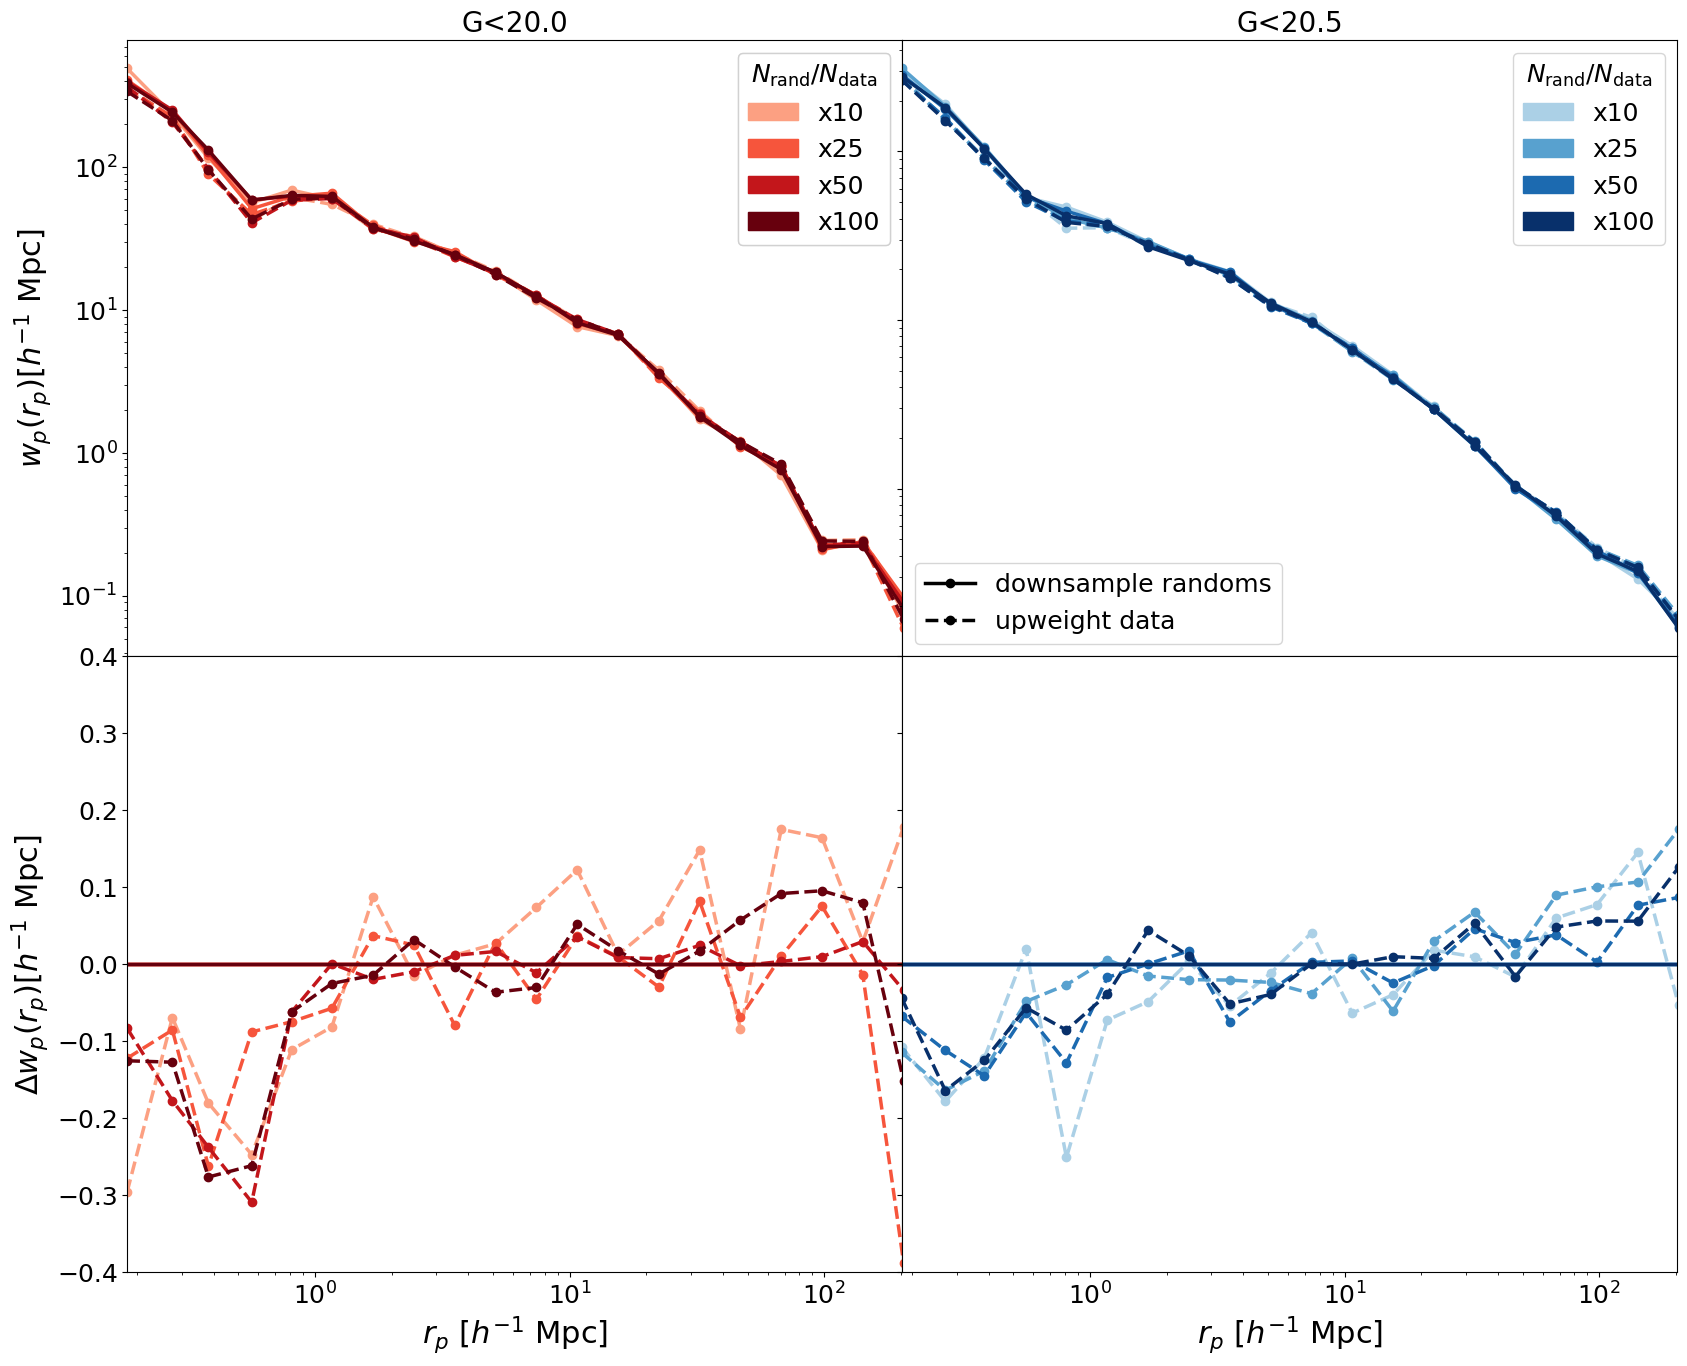

In [24]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0)
    
for i in range(len(colors)):

    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])
    
    for j in range(len(facrand)):

        ax1.plot(rpavg_test[G_array[i]][j], wp_test[G_array[i]][j], marker = 'o', label = 'downsample randoms', 
                     linewidth = 2.5, color = cmaps[i][j])

        # upweighted method
        ax1.plot(rpavg_test_allsky[G_array[i]][j], wp_test_allsky[G_array[i]][j], marker = 'o', label = 'upweight data', 
                     linewidth = 2.5, color = cmaps[i][j], linestyle = '--')

        ax1.set_title('G<{}'.format(G_array[i]))
        ax1.set_xticklabels([])
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        # ax1.set_ylim(8e-4, 3e1)

        ax2.axhline(0, linewidth = 2.5,color = cmaps[i][j])
        ax2.plot(rpavg_test_allsky[G_array[i]][j], (wp_test_allsky[G_array[i]][j]-wp_test[G_array[i]][j])/wp_test[G_array[i]][j], marker = 'o', 
                 label = 'x{}'.format(facrand[j]), linewidth = 2.5, color = cmaps[i][j], linestyle = '--')
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax2.set_ylim(-0.4, 0.4)

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if i == 0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
            ax2.set_ylabel(r"$\Delta w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])
            
    patch = [mpatches.Patch(color=cmaps[i][k], label='x{}'.format(facrand[k])) for k in range(len(cmaps[i]))]
    first_legend = ax1.legend(handles=patch, loc = 'upper right', title = "$N_\mathrm{rand}/N_\mathrm{data}$", title_fontsize = 18)
    ax1.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '-', marker = 'o'), 
                Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '--', marker = 'o')]
ax1.legend(custom_lines, ['downsample randoms', 'upweight data'], loc = 'lower left')

plt.show()

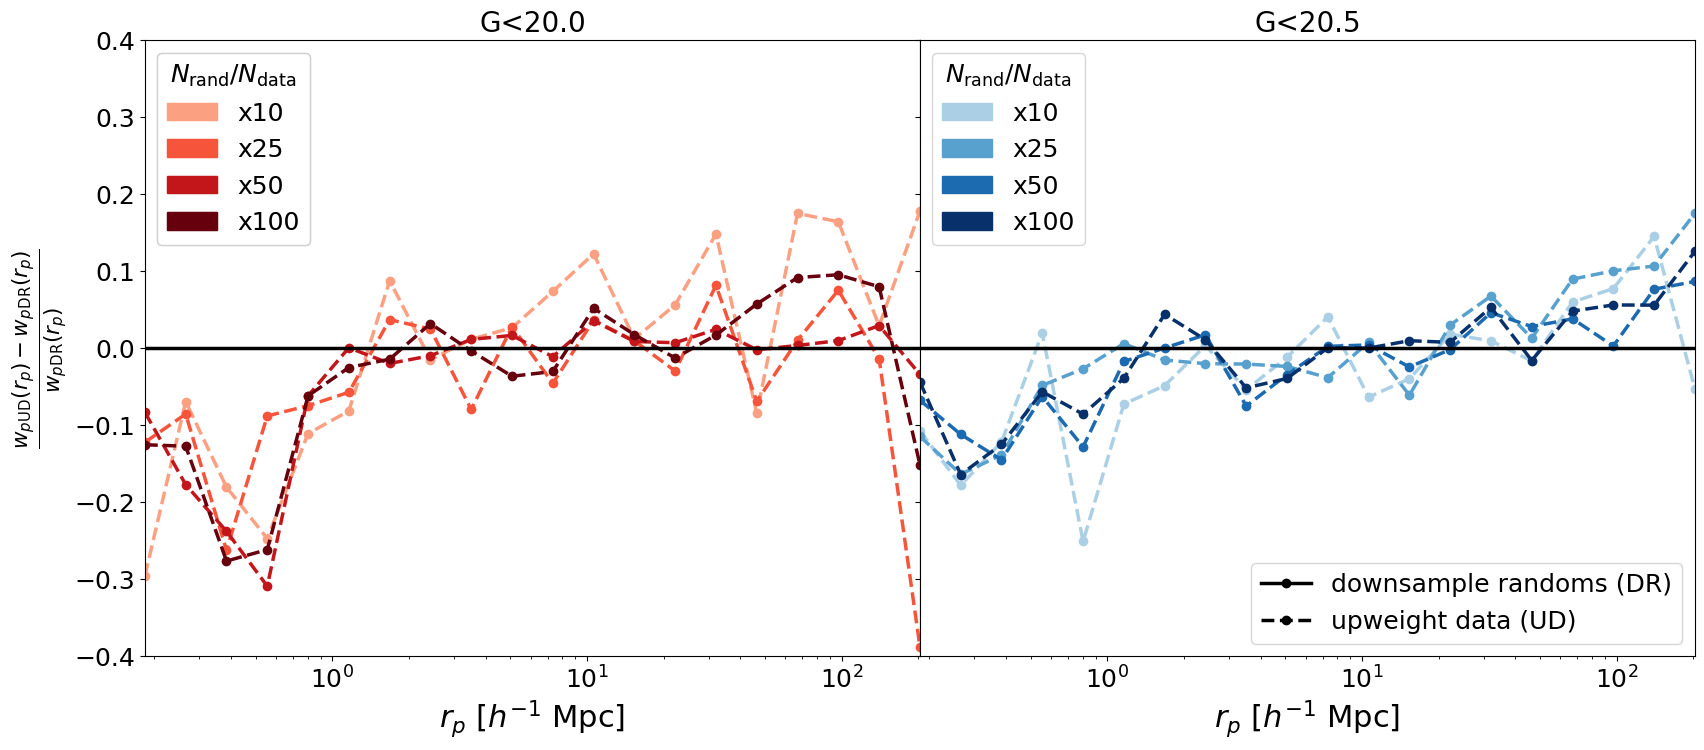

In [25]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

for i in range(len(colors)):

    ax1 = fig.add_subplot(gs[i])
    
    for j in range(len(facrand)):

        ax1.plot(quaia.recenter(rbins), (wp_test_allsky[G_array[i]][j]-wp_test[G_array[i]][j])/wp_test[G_array[i]][j], marker = 'o', 
                 label = 'x{}'.format(facrand[j]), linewidth = 2.5, color = cmaps[i][j], linestyle = '--')
    
    ax1.set_title('G<{}'.format(G_array[i]))    
    ax1.axhline(0, linewidth = 2.5,color = 'black')
    ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(-0.4, 0.4)

    if scale == 'log':
        ax1.set_xscale('log')

    if i == 0:
        ax1.set_ylabel(r"$\frac{{w_p}_\mathrm{UD}(r_p)-{w_p}_\mathrm{DR}(r_p)}{{w_p}_\mathrm{DR}(r_p)}$")
    else:
        ax1.set_yticklabels([])

    patch = [mpatches.Patch(color=cmaps[i][k], label='x{}'.format(facrand[k])) for k in range(len(cmaps[i]))]
    first_legend = ax1.legend(handles=patch, loc = 'upper left', title = "$N_\mathrm{rand}/N_\mathrm{data}$", title_fontsize = 18)
    ax1.add_artist(first_legend)
    
custom_lines = [Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '-', marker = 'o'), 
                Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '--', marker = 'o')]
ax1.legend(custom_lines, ['downsample randoms (DR)', 'upweight data (UD)'], loc = 'lower right')

plt.show()